In [2]:
import os
import torch
import torchvision
from torch.utils.data import DataLoader
import random
import sys

import annoy
import json

sys.path.insert(0, os.path.abspath("."))

import matplotlib.pyplot as plt

import torch
import numpy as np
from sklearn.decomposition import PCA
from tqdm import tqdm

from torchvision import transforms
from VAE import ConvVAE, load_checkpoint   # latent-space addition


random.seed(73)
torch.manual_seed(73)
CELEBA_MEAN = [0.5, 0.5, 0.5]
CELEBA_STD  = [0.5, 0.5, 0.5]

data_root  = 'local_datasets/celeba'
image_size = 64
LATENT_DIM = 128    # dimension of latent z  (replaces 64*64*3 in the pixel-space notebook)

celeba_data = torchvision.datasets.ImageFolder(root=data_root, transform=transforms.Compose([
                                  transforms.Resize(image_size),
                                  transforms.CenterCrop(image_size),
                                  transforms.ToTensor(),
                                  transforms.Normalize(mean=CELEBA_MEAN,
                                                       std=CELEBA_STD)
                              ]))

celeba_loader = DataLoader(
    celeba_data, batch_size=64, shuffle=False,
    num_workers=4, pin_memory=True
)

print(celeba_data)

# Load trained VAE encoder / decoder
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = ConvVAE(in_channels=3, image_size=image_size, latent_dim=LATENT_DIM).to(device)
load_checkpoint(vae, "output/models/vae/vae_celeba_epoch_020.pt", device)
vae.eval()
print(f"VAE loaded on {device}")


Dataset ImageFolder
    Number of datapoints: 202599
    Root location: local_datasets/celeba
    StandardTransform
Transform: Compose(
               Resize(size=64, interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(64, 64))
               ToTensor()
               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
           )
Checkpoint loaded ← output/models/vae/vae_celeba_epoch_020.pt
VAE loaded on cpu


## Build Latent kNN Index


In [2]:
knn_index = annoy.AnnoyIndex(LATENT_DIM, 'euclidean')   # was annoy.AnnoyIndex(64*64*3, ...)

name_map = dict()
name_idx = 0
with torch.no_grad():
    for img, name in tqdm(celeba_data, desc="Encode images to latent z for ANN"):
        # z_np = mu.squeeze(0).cpu().numpy()
        z_np = vae.encode(img.unsqueeze(0).to(device))[0].squeeze(0).cpu().numpy()  # mu(x)
        name_map[name] = name_idx
        knn_index.add_item(name_idx, z_np)   # was: img.numpy().flatten()
        name_idx += 1

knn_index.build(50)

knn_index.save('celeba_latent_knn_ds.ann')
with open('celeba_latent_knn_ds_indexmap.json', 'w') as f:
    json.dump(name_map, f)


Encode images to latent z for ANN: 100%|██████████| 202599/202599 [56:34<00:00, 59.68it/s]  


(500, 128)
(500, 128)
(500, 128)


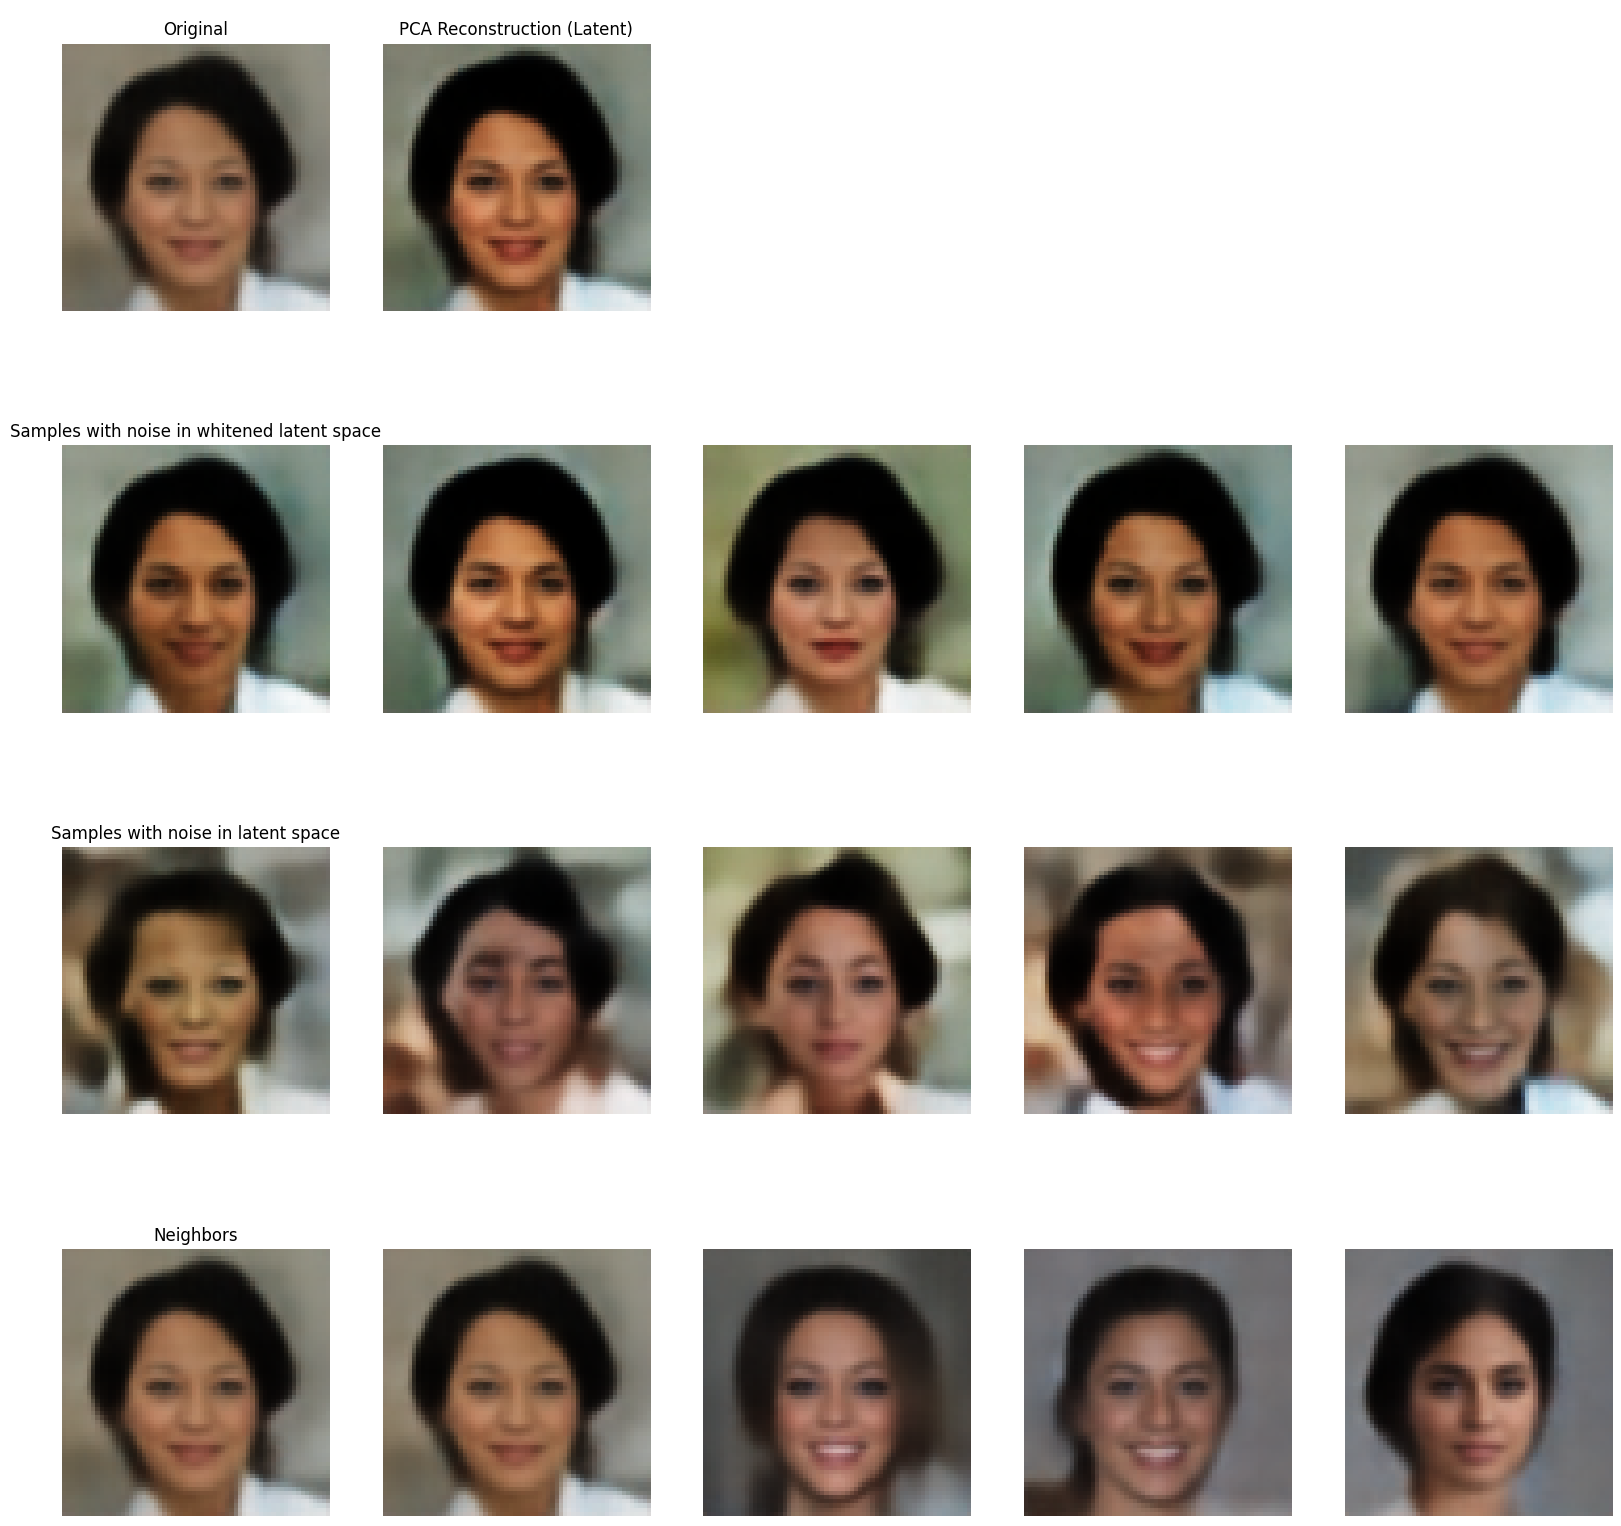

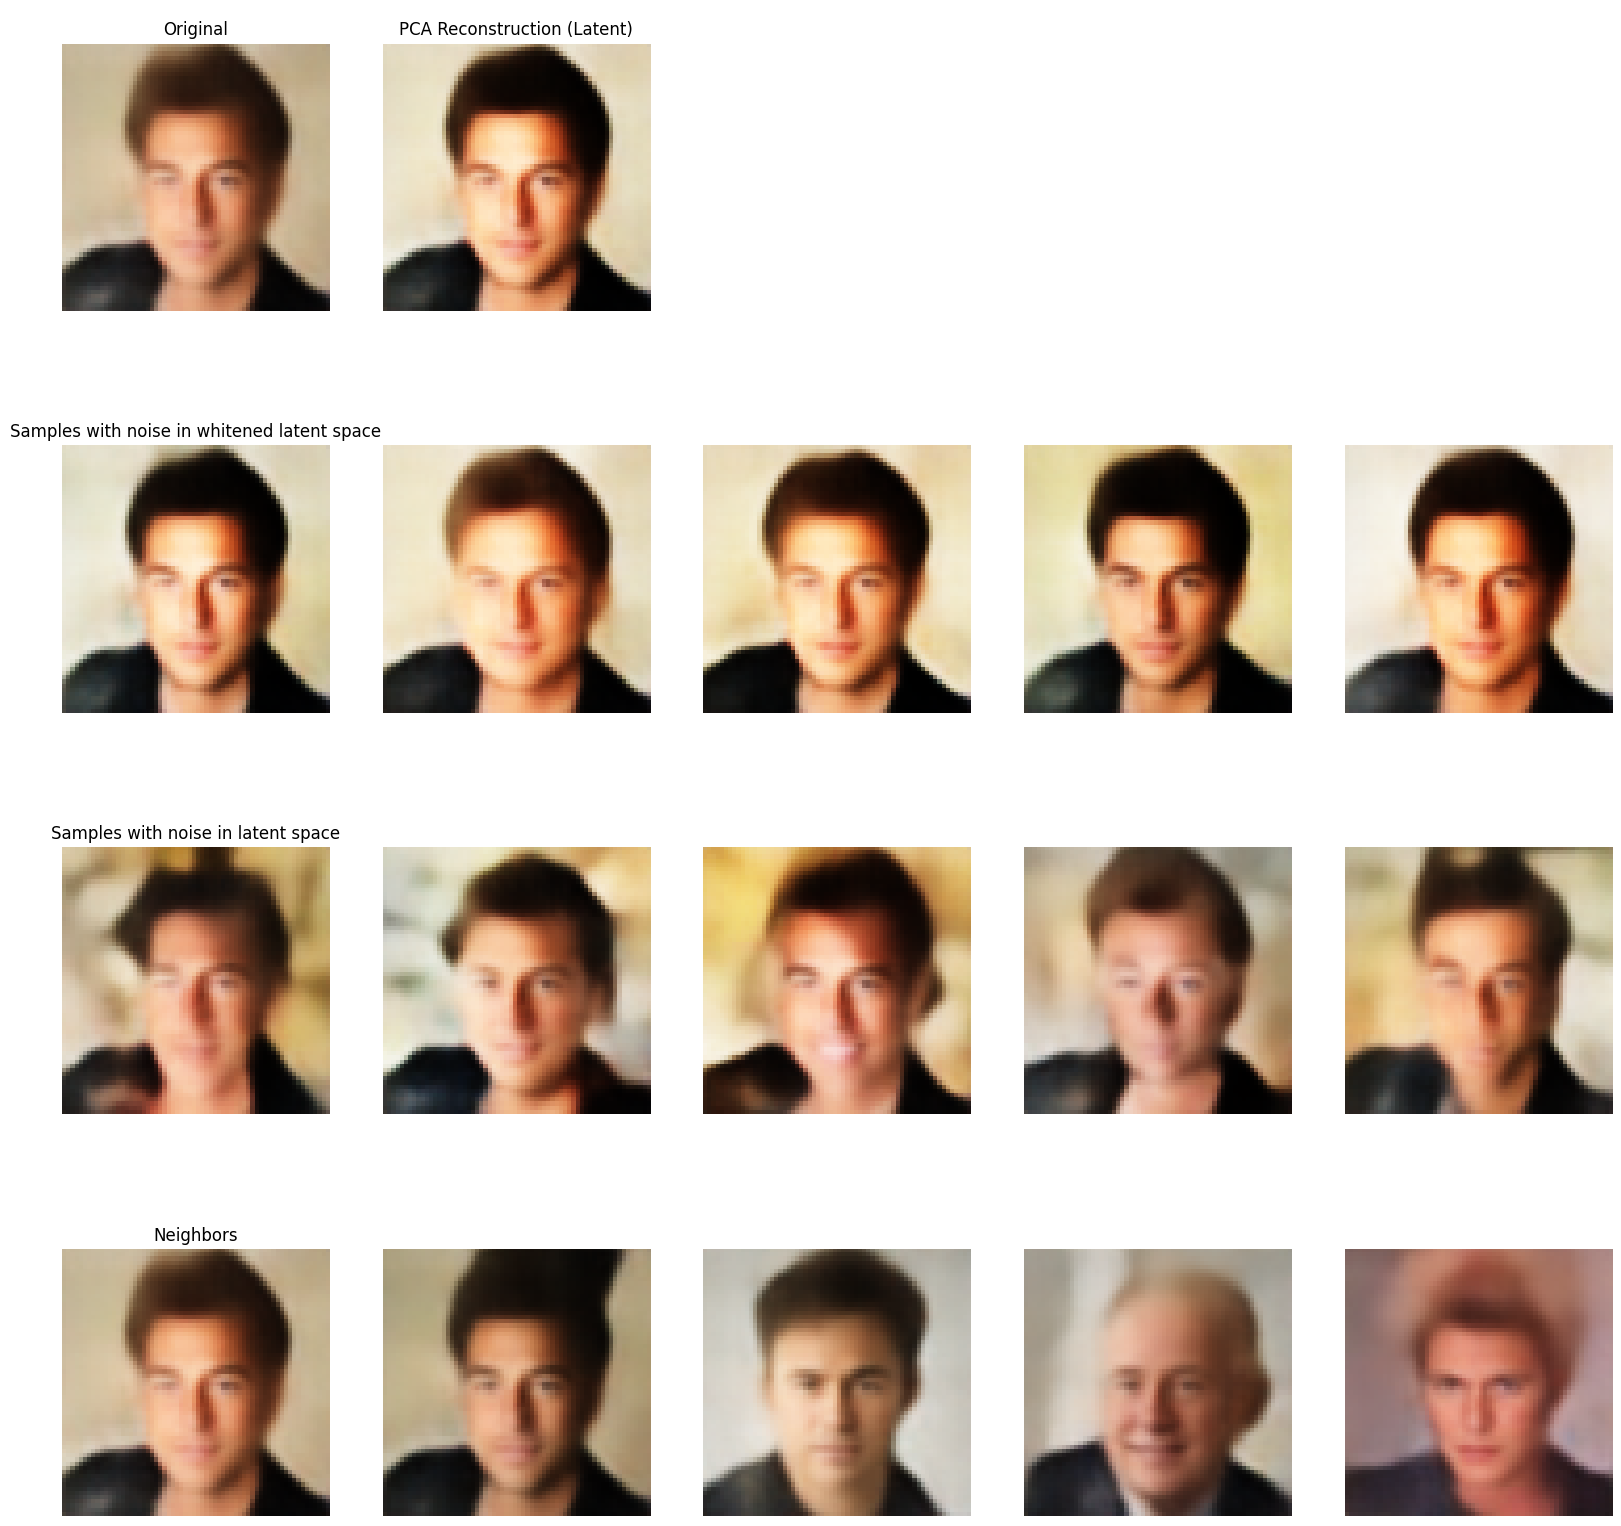

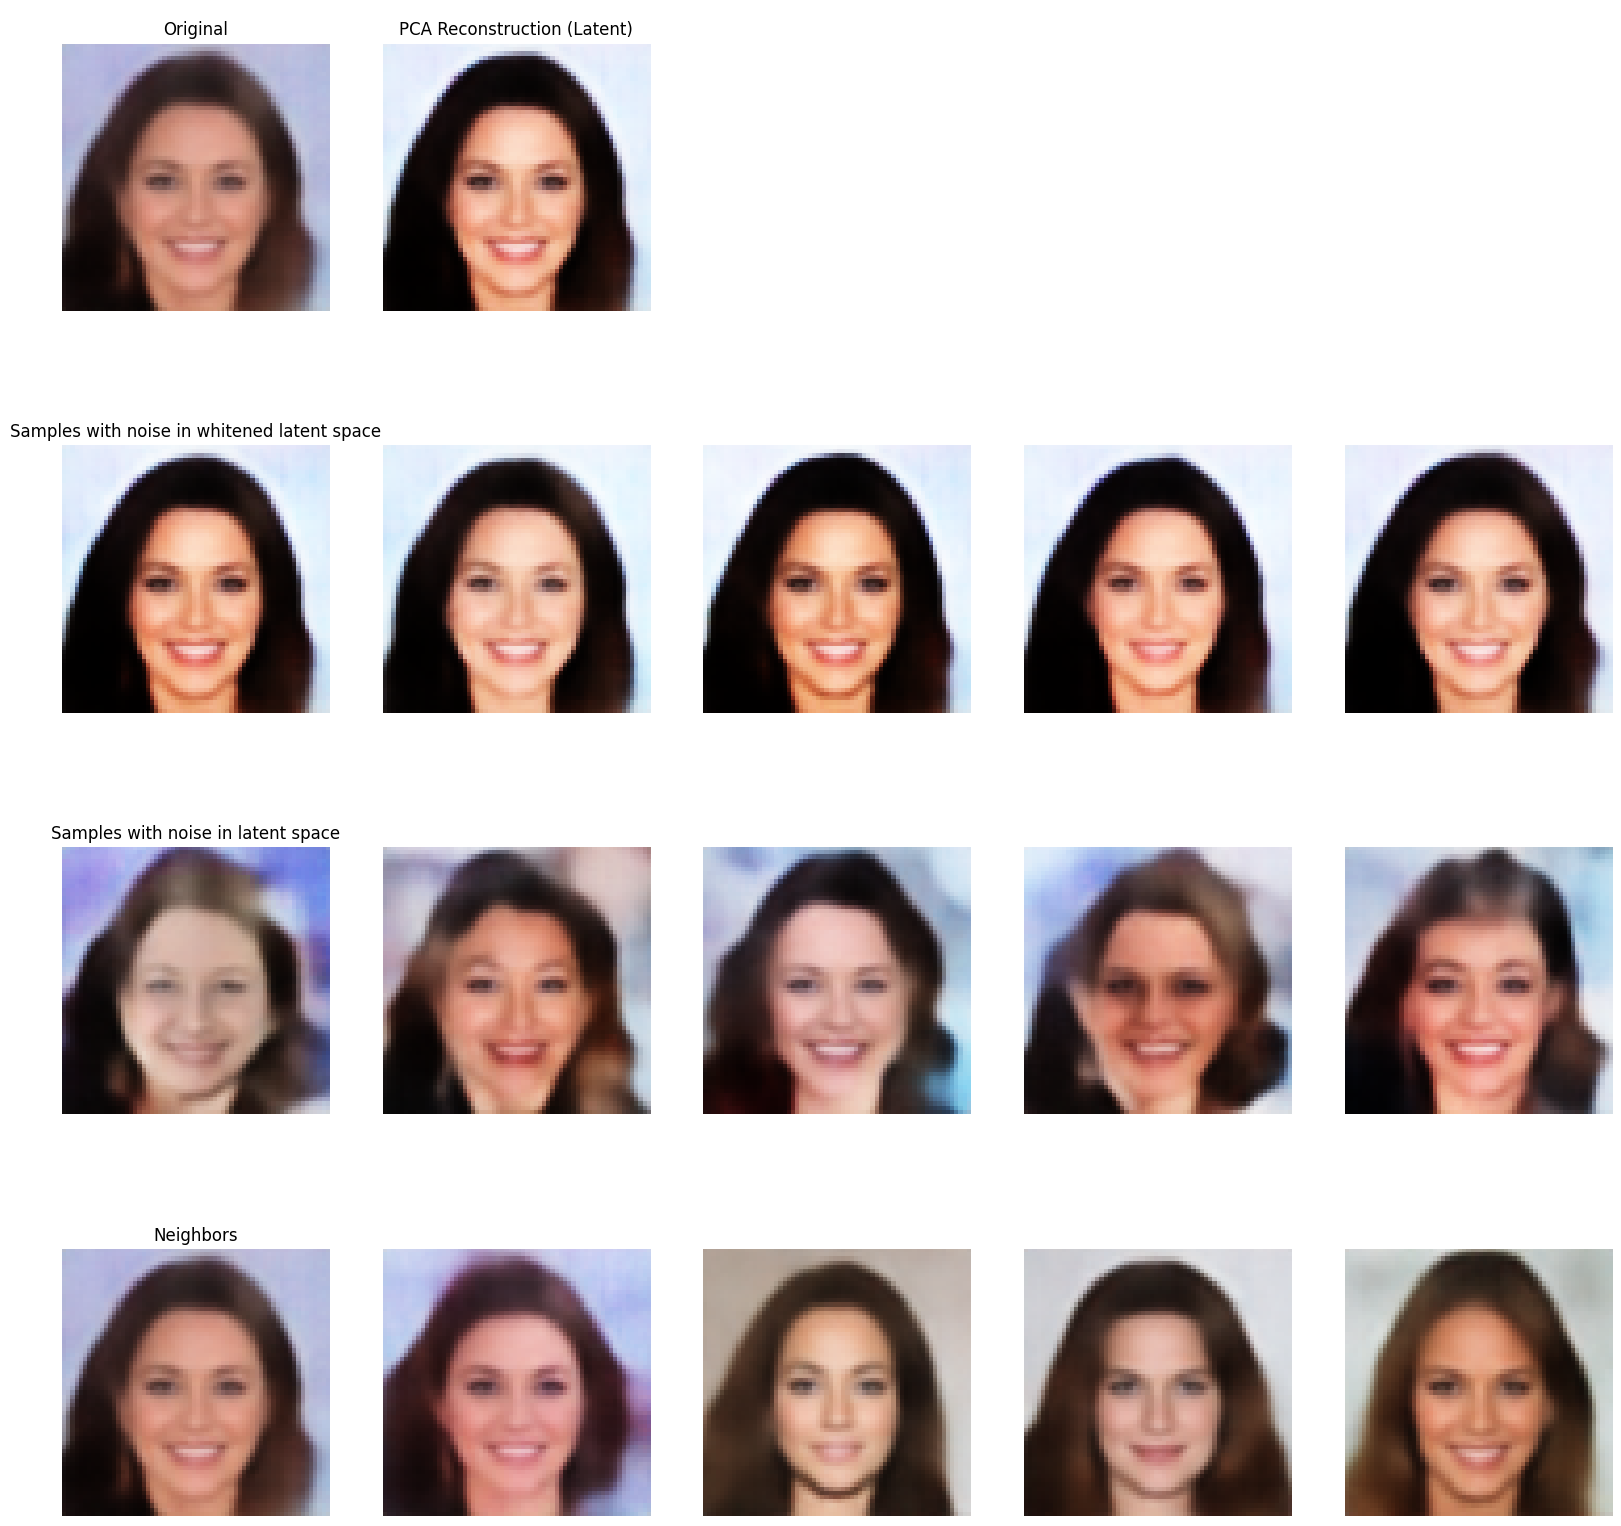

In [3]:
knn_index = annoy.AnnoyIndex(LATENT_DIM, 'euclidean')   # was 64*64*3

knn_index.load('celeba_latent_knn_ds.ann')


scale_weight = 0.7


def unnormalize_np(img):
    return np.add(np.multiply(img, CELEBA_STD), CELEBA_MEAN)


def to_latent_np(z_like):
    """Convert Annoy list or tensor-like latent vector to 1D float32 numpy array."""
    z = np.asarray(z_like, dtype=np.float32)
    if z.ndim != 1:
        z = z.reshape(-1)
    return z


def decode_z_to_img(z_np):
    """Decode a latent z vector to a displayable HWC image.
    Replaces: unnormalize_np(np.permute_dims(np.reshape(x_flat, shape), (1,2,0)))
    """
    z_np = to_latent_np(z_np)
    with torch.no_grad():
        z_t = torch.from_numpy(z_np[None, :]).to(device=device, dtype=torch.float32)
        x_hat = vae.decode(z_t).squeeze(0).cpu().numpy()   # (C, H, W), normalised
    return unnormalize_np(np.permute_dims(x_hat, (1, 2, 0)))


target_idcs = [100, 51, 42]

for target_idx in target_idcs:

    X_img, X_class = celeba_data[target_idx]  # our x
    k = 500
    X_nns_idcs = knn_index.get_nns_by_item(target_idx, k)

    X_local_n = []
    for i in X_nns_idcs:
        X_local_n.append(to_latent_np(knn_index.get_item_vector(i)))
    X_local_n = np.stack(X_local_n)
    print(X_local_n.shape)

    # original image decoded from latent z
    X_orig_flat = to_latent_np(knn_index.get_item_vector(target_idx))   # latent z vector (was flat pixel vector)
    orig_img = decode_z_to_img(X_orig_flat)               # was: unnormalize_np(permute(reshape(...)))

    ## Get mean and recenter
    mean_local_n = np.mean(X_local_n, 0)
    X_local_n = X_local_n - mean_local_n

    ## Compute PCA space for the neighborhood
    n_components = min(k, LATENT_DIM)   # latent dim caps components (was simply k)
    pca = PCA(n_components=n_components)
    pca.fit(X_local_n)
    ev = pca.explained_variance_
    Vt = pca.components_

    X_whitened = np.matmul(X_orig_flat, (1/np.sqrt(ev)) * np.transpose(Vt))

    Z_recon = np.matmul(X_whitened, np.transpose(np.sqrt(ev)*np.transpose(Vt))) + mean_local_n
    orig_rec = decode_z_to_img(Z_recon)                   # was: unnormalize_np(permute(reshape(...)))

    n_samples = 5
    fig, axes = plt.subplots(4, 5, figsize=(20, 20))
    for ax in axes.flat:
        ax.axis("off")

    axes[0, 0].imshow(orig_img)
    axes[0, 0].set_title("Original")
    axes[0, 0].axis("off")
    axes[0, 1].imshow(orig_rec)
    axes[0, 1].set_title("PCA Reconstruction (Latent)")
    axes[0, 1].axis("off")


    # noisy samples — noise added in whitened latent space
    for i in range(n_samples):
        X_noised = X_whitened + np.random.normal(np.repeat(0, n_components), np.pow(scale_weight, 2))

        ## Transform back to latent space, add mean, decode to image
        Z_noised = np.matmul(X_noised, np.transpose(np.sqrt(ev)*np.transpose(Vt))) + mean_local_n
        rec_img = decode_z_to_img(Z_noised)               # was: unnormalize_np(permute(reshape(...)))
        ax = axes[(i // 5)+1, i % 5]
        if i == 0:
            ax.set_title("Samples with noise in whitened latent space")
        ax.imshow(rec_img)
        ax.axis("off")

    # noisy samples — isotropic noise directly in latent space
    for i in range(n_samples):
        Z_noised = X_orig_flat + np.random.normal(np.repeat(0, np.shape(X_orig_flat)), np.pow(scale_weight, 2))
        rec_img = decode_z_to_img(Z_noised)               # was: unnormalize_np(permute(reshape(...)))
        ax = axes[((i+1*n_samples) // 5)+1, (i+1*n_samples) % 5]
        if i == 0:
            ax.set_title("Samples with noise in latent space")
        ax.imshow(rec_img)
        ax.axis("off")

    for i, target_i in enumerate(X_nns_idcs[0:5]):
        Z_nn = to_latent_np(knn_index.get_item_vector(target_i))
        nn_img = decode_z_to_img(Z_nn)                    # was: unnormalize_np(permute(reshape(...)))
        ax = axes[((i+2*n_samples) // 5)+1, (i+2*n_samples) % 5]
        if i == 0:
            ax.set_title("Neighbors")
        ax.imshow(nn_img)
        ax.axis("off")

    scale_single_weight = scale_weight/2

In [ ]:
from scipy.stats import norm
# TODO : Validate the certificate radius with a small Monte Carlo simulation, by sampling points in the whitened latent space and checking if they decode to images that are close to the original in pixel space 
# Certified radius 

demo_idx = 100

with torch.no_grad():
    x_demo, _ = celeba_data[demo_idx]
    mu_t, logvar_t = vae.encode(x_demo.unsqueeze(0).to(device))

mu_demo     = mu_t.squeeze(0).cpu().numpy()
logvar_demo = logvar_t.squeeze(0).cpu().numpy()

# Local PCA around demo point (reuse variables from the loop above)
nn_idcs  = knn_index.get_nns_by_item(demo_idx, 500)
Z_local  = np.stack([knn_index.get_item_vector(i) for i in nn_idcs])
Z_local -= Z_local.mean(0)

pca_cert = PCA(n_components=min(500, LATENT_DIM))
pca_cert.fit(Z_local)
ev_cert  = pca_cert.explained_variance_
Vt_cert  = pca_cert.components_

# Combined blended covariance: Sigma_z = Sigma_knn + lambda * diag(sigma_vae^2)
blend_lambda = 0.2
ev_blend = np.maximum(ev_cert + blend_lambda * np.exp(logvar_demo), 1e-8)

# Whitening transform  T = Lambda^{-1/2} U^T
T = (np.diag(1.0 / np.sqrt(ev_blend)) @ Vt_cert).astype(np.float32)

# certified radius in whitened latent coordinates
alpha = scale_weight
r_white = 0.5 * alpha * (norm.ppf(0.90) - norm.ppf(0.05))

print(f"demo_idx : {demo_idx}")
print(f"T shape  : {T.shape}")
print(f"Certified radius (whitened latent): {r_white:.4f}")
print("Certificate: { z : ||T(z - z0)||₂ ≤ r } in latent space.")


demo_idx : 100
T shape  : (128, 128)
Certified radius (whitened latent): 1.0242
Certificate: { z : ||T(z - z0)||₂ ≤ r } in latent space.


In [ ]:
# how to Check if a perturbed z falls inside the certificate
z_perturbed = mu_demo + np.random.randn(LATENT_DIM) * 0.01
dist_whitened = np.linalg.norm(T @ (z_perturbed - mu_demo))
is_certified = dist_whitened <= r_white
print(f"Whitened distance: {dist_whitened:.4f}, radius: {r_white:.4f}, certified: {is_certified}")

Whitened distance: 0.4021, radius: 1.0242, certified: True
